In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import kagglehub
import os
import osmnx as ox
import geopandas as gpd
from pathlib import Path
from pandas import DataFrame

plt.style.use("seaborn-v0_8")

In [66]:
project_report_images_path = Path('../ProjectReport/Images/')
project_report_tables_path = Path('../ProjectReport/Tables/')
data_path = Path('../data')

In [67]:
apartments = pd.read_csv("../data/apartments.csv")
apartments

,price_numeric,municipality,condition,ad_type,rooms,square_m2,equipment,level,heating,price_per_m2,latitude,longitude
0,80.0,Sarajevo - Novo Sarajevo,Renovated,Rent,2.0,62.0,Furnished,16,District Heating,1.290323,43.850305,18.374470
1,100.0,Vogošća,New Build,Rent,2.0,20.0,Furnished,-1,Central (Boiler Room),5.000000,43.901206,18.354117
2,200.0,Sarajevo - Novi Grad,Good Condition,Rent,1.0,30.0,Furnished,1,Central (Boiler Room),6.666667,43.800453,18.246421
3,250.0,Sarajevo - Novo Sarajevo,Good Condition,Rent,2.0,48.0,Unfurnished,0,Electric Heating,5.208333,43.858893,18.399583
4,250.0,Sarajevo - Novi Grad,Good Condition,Rent,2.0,40.0,Furnished,0,Central (Boiler Room),6.250000,43.875628,18.315744
...,...,...,...,...,...,...,...,...,...,...,...,...
844,1000000.0,Sarajevo - Centar,Good Condition,Sale,3.0,124.0,Unfurnished,0,Gas Heating,8064.516129,43.853746,18.404423
845,1050000.0,Sarajevo - Novi Grad,New Build,Sale,4.0,146.0,Furnished,8,Central (Boiler Room),7191.780822,43.846929,18.374245
846,1191000.0,Sarajevo - Novo Sarajevo,New Build,Sale,4.0,203.0,Furnished,9,District Heating,5866.995074,43.846926,18.374029
847,1191000.0,Sarajevo - Novi Grad,New Build,Sale,4.0,203.0,Furnished,9,District Heating,5866.995074,43.847530,18.375606


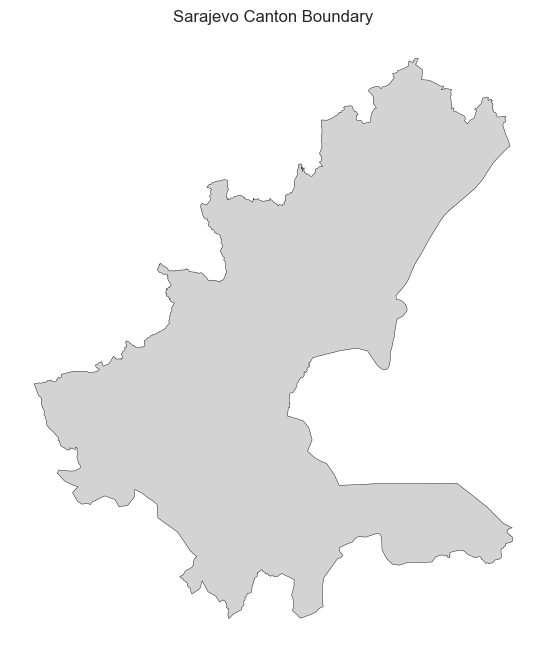

EPSG:32634


In [68]:
place = "Sarajevo Canton, Bosnia and Herzegovina"

canton = ox.geocode_to_gdf(place).to_crs(epsg=32634)

fig, ax = plt.subplots(figsize=(8, 8))
canton.plot(ax=ax, facecolor="lightgrey", edgecolor="black")
ax.set_title("Sarajevo Canton Boundary")
ax.axis("off")
plt.show()

print(canton.crs)

In [69]:
apartments_gdf = gpd.GeoDataFrame(
    apartments,
    geometry=gpd.points_from_xy(apartments['longitude'], apartments['latitude'], crs="EPSG:4326"),
    crs="EPSG:4326"
).to_crs("EPSG:32634")

apartments_clipped = apartments_gdf.clip(canton)


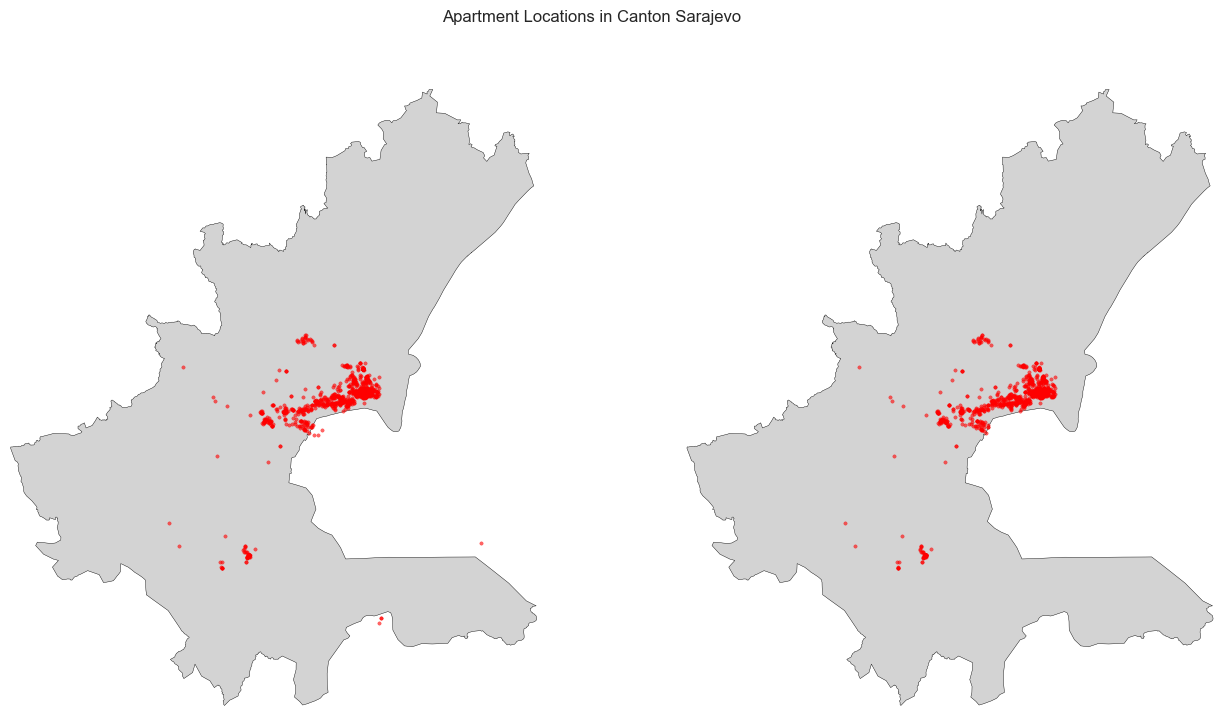

In [70]:
minx, miny, maxx, maxy = canton.total_bounds

plt.subplots(figsize=(16, 8), nrows=1, ncols=2)

ax = plt.subplot(1,2,1)
canton.plot(ax=ax, facecolor="lightgrey", edgecolor="black")
apartments_gdf.plot(
    ax=ax,
    color="red",
    markersize=6,
    alpha=0.6
)
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.axis("off")

ax = plt.subplot(1,2,2)
canton.plot(ax=ax, facecolor="lightgrey", edgecolor="black")
apartments_clipped.plot(
    ax=ax,
    color="red",
    markersize=6,
    alpha=0.6
)

# Force view to canton extent
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.axis("off")

plt.suptitle("Apartment Locations in Canton Sarajevo")

plt.savefig(project_report_images_path / "distribution_of_apartments.pdf")
plt.show()


In [71]:
removed_apartments = apartments.loc[
    ~apartments.index.isin(apartments_clipped.index)
]

removed_apartments

,price_numeric,municipality,condition,ad_type,rooms,square_m2,equipment,level,heating,price_per_m2,latitude,longitude
13,400.0,Sarajevo - Novi Grad,New Build,Rent,1.0,35.0,Furnished,3,Central Gas Heating,11.428571,43.820528,18.360500
39,550.0,Sarajevo - Centar,Good Condition,Rent,1.0,38.0,Furnished,4,District Heating,14.473684,44.770647,17.213587
46,550.0,Sarajevo - Novo Sarajevo,Renovated,Rent,2.0,44.0,Furnished,4,District Heating,12.500000,43.825377,18.369031
67,650.0,Sarajevo - Novi Grad,New Build,Rent,3.0,86.0,Semi-Furnished,4,District Heating,7.558140,43.820686,18.365006
106,750.0,Ilidža,New Build,Rent,3.0,57.0,Furnished,6,District Heating,13.157895,43.827596,18.357962
120,800.0,Sarajevo - Novi Grad,New Build,Rent,3.0,64.0,Furnished,4,Central Gas Heating,12.500000,43.829350,18.358322
322,142000.0,Sarajevo - Novi Grad,Good Condition,Sale,2.0,57.3,Furnished,6,Electric Heating,2478.184991,41.194595,19.523676
323,144100.0,Sarajevo - Novi Grad,New Build,Sale,2.0,53.0,Unfurnished,2,Electric Heating,2718.867925,41.232957,19.521073
325,149500.0,Trnovo,New Build,Sale,2.0,30.0,Semi-Furnished,1,Electric Heating,4983.333333,43.665483,18.446512
380,205816.0,Trnovo,Under Construction,Sale,2.0,39.0,Unfurnished,2,Electric Heating,5277.333333,43.661107,18.443999


In [72]:
POI_TAGS = {
    # Healthcare
    "hospital": {"amenity": "hospital"},
    "clinic": {"amenity": "clinic"},
    "pharmacy": {"amenity": "pharmacy"},

    # Education
    "school": {"amenity": "school"},
    "university": {"amenity": "university"},
    "kindergarten": {"amenity": "kindergarten"},

    # Transport
    "bus_stop": {"highway": "bus_stop"},
    "tram_stop": {"railway": "tram_stop"},
    "train_station": {"railway": "station"},
    "parking": {"amenity": "parking"},

    # Environment
    "park": {"leisure": "park"},
    "playground": {"leisure": "playground"},

    # Commerce
    "mall": {"shop": "mall"},
    "supermarket": {"shop": "supermarket"},
    "marketplace": {"amenity": "marketplace"},

    # Urban
    "restaurant": {"amenity": "restaurant"},
    "cafe": {"amenity": "cafe"},

    # Religion
    "place_of_worship": {"amenity": "place_of_worship"},

    # Safety & public services
    "police": {"amenity": "police"},
    "fire_station": {"amenity": "fire_station"},
    "post_office": {"amenity": "post_office"},

    # Sports & lifestyle
    "sports_centre": {"leisure": "sports_centre"},
    "fitness_centre": {"leisure": "fitness_centre"},
    "stadium": {"leisure": "stadium"},
}

In [73]:
poi_data = {}

for name, tags in POI_TAGS.items():
    gdf = ox.features.features_from_place(place, tags).to_crs(epsg=32634)
    # Keep only points (some POIs are polygons)
    gdf = gdf[gdf.geometry.type.isin(["Point", "Polygon"])]

    # Convert polygons to centroids
    gdf["geometry"] = gdf.geometry.centroid

    poi_data[name] = gdf

<Figure size 1000x800 with 0 Axes>

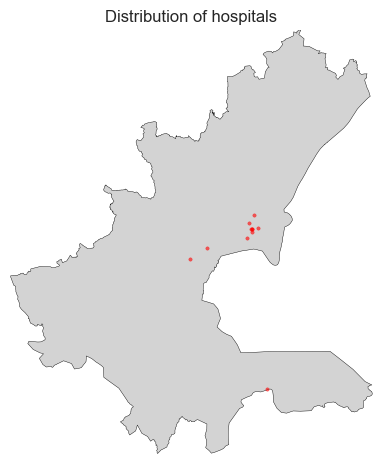

<Figure size 1000x800 with 0 Axes>

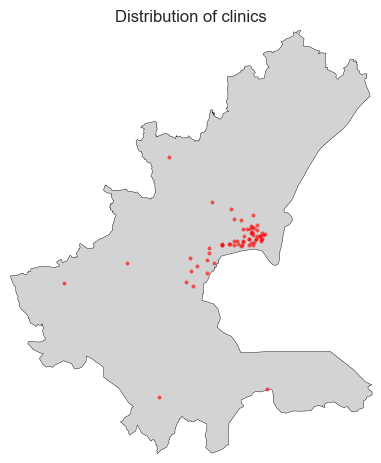

<Figure size 1000x800 with 0 Axes>

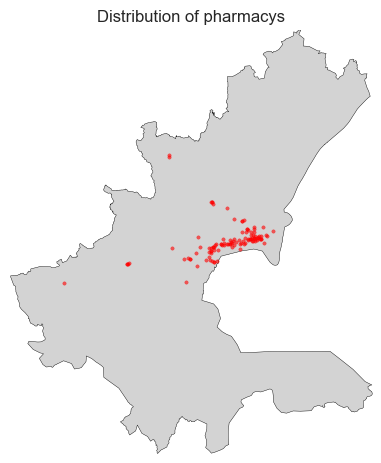

<Figure size 1000x800 with 0 Axes>

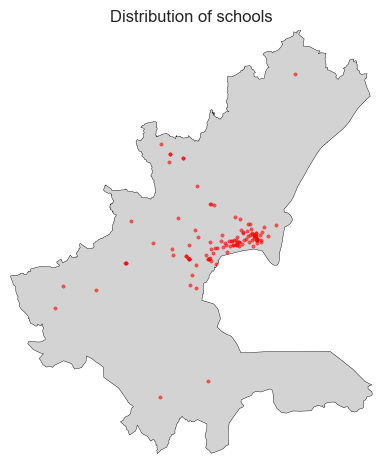

<Figure size 1000x800 with 0 Axes>

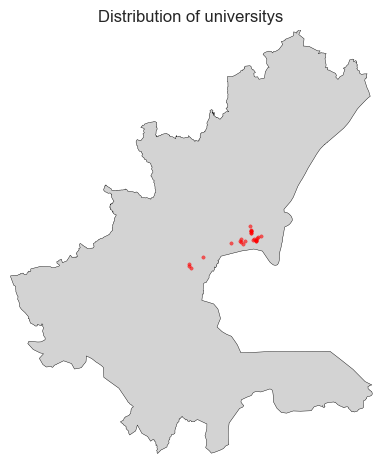

<Figure size 1000x800 with 0 Axes>

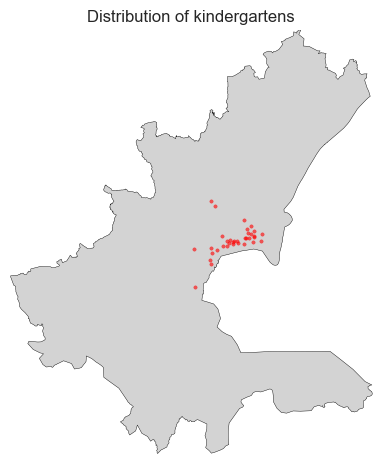

<Figure size 1000x800 with 0 Axes>

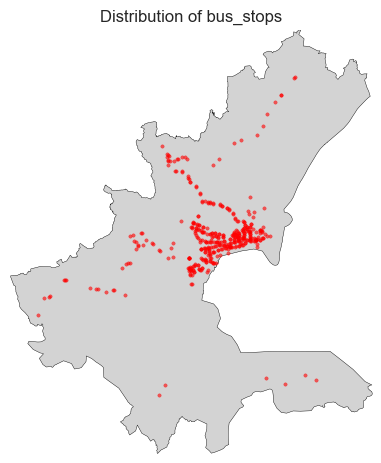

<Figure size 1000x800 with 0 Axes>

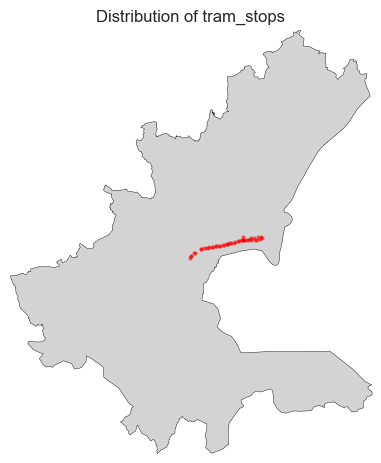

<Figure size 1000x800 with 0 Axes>

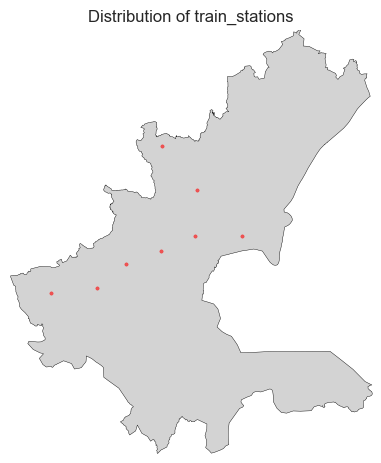

<Figure size 1000x800 with 0 Axes>

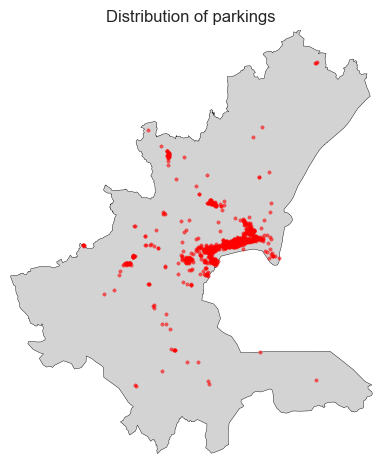

<Figure size 1000x800 with 0 Axes>

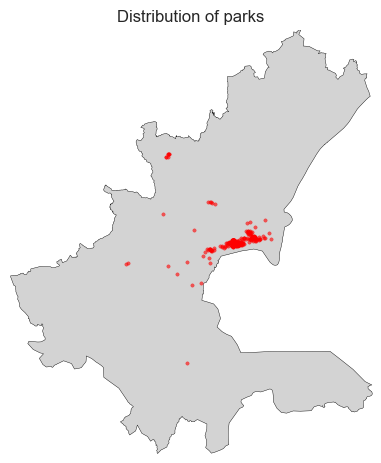

<Figure size 1000x800 with 0 Axes>

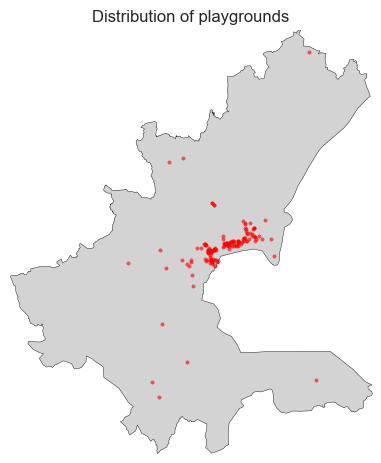

<Figure size 1000x800 with 0 Axes>

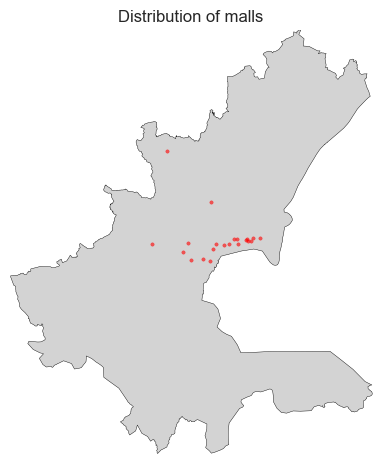

<Figure size 1000x800 with 0 Axes>

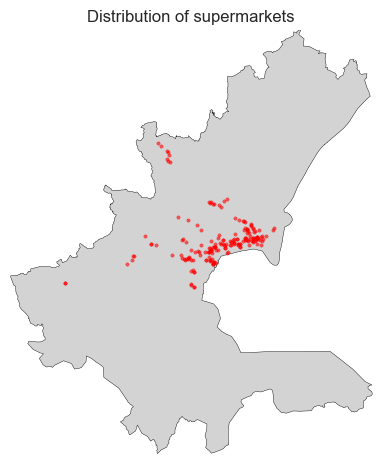

<Figure size 1000x800 with 0 Axes>

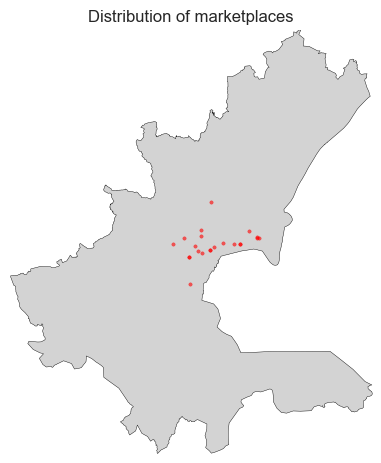

<Figure size 1000x800 with 0 Axes>

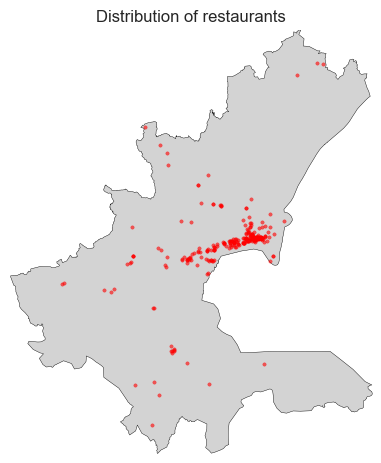

<Figure size 1000x800 with 0 Axes>

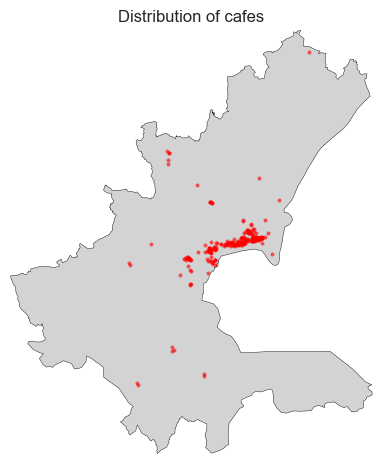

<Figure size 1000x800 with 0 Axes>

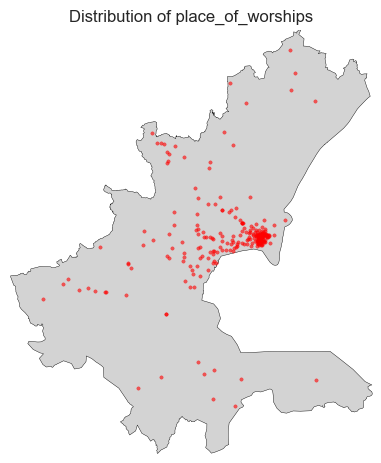

<Figure size 1000x800 with 0 Axes>

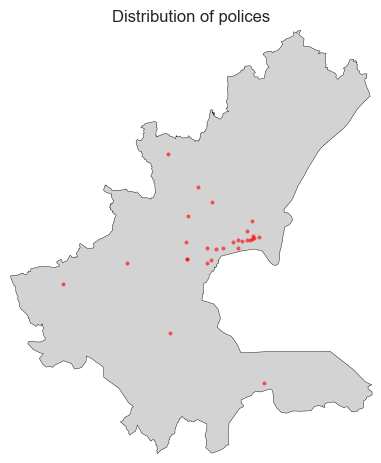

<Figure size 1000x800 with 0 Axes>

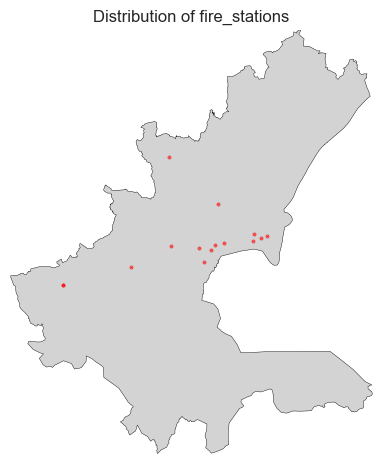

<Figure size 1000x800 with 0 Axes>

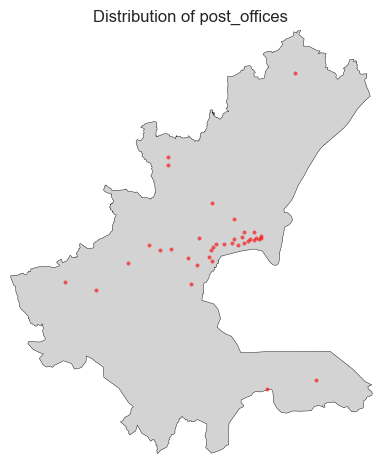

<Figure size 1000x800 with 0 Axes>

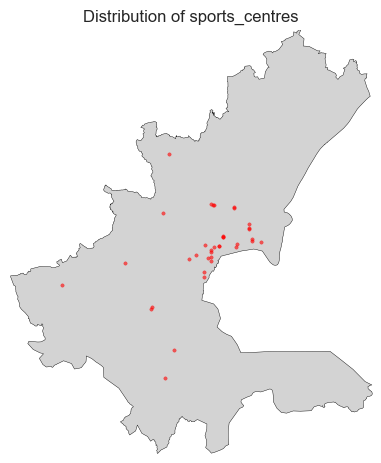

<Figure size 1000x800 with 0 Axes>

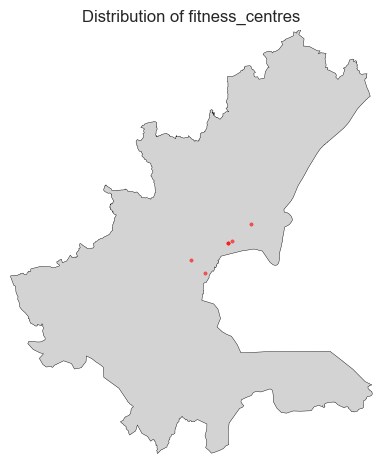

<Figure size 1000x800 with 0 Axes>

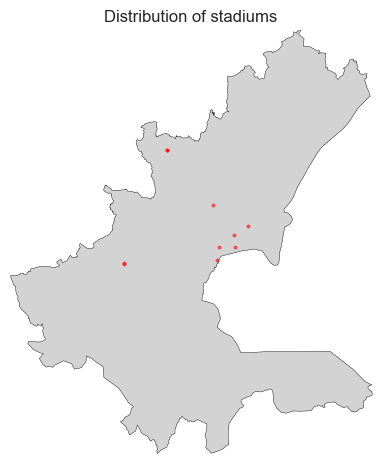

In [74]:
for feature in poi_data.keys():
    plt.figure(figsize=(10, 8))
    ax = canton.plot(facecolor="lightgrey", edgecolor="black")
    poi_data[feature].plot(ax=ax, color="red", markersize=6, alpha=0.6)
    ax.set_xlim(minx, maxx);ax.set_ylim(miny, maxy);ax.axis("off")
    plt.title(f"Distribution of {feature}s")

    plt.savefig(project_report_images_path / f"distribution_of_{feature}s.pdf")
    plt.show()
    plt.close()

In [75]:
poi_data['university'].dropna(axis="columns", how="any").explore()

In [76]:
from shapely.geometry import Point

def compute_distance(s : pd.Series):
    # Create point in WGS84
    point = Point(s["longitude"], s["latitude"])
    point = gpd.GeoSeries([point], crs="EPSG:4326").to_crs(epsg=32634).iloc[0]

    for poi_name, pois in poi_data.items():
        if pois.empty:
            s[f"closest_{poi_name}_m"] = np.nan
            continue

        idx = pois.sindex.nearest(point, 1)[1][0]
        nearest_geom = pois.geometry.iloc[idx]

        s[f"closest_{poi_name}_m"] = point.distance(nearest_geom)

    return s

apartments = apartments_clipped.apply(compute_distance, axis="columns")

In [77]:
apartments

,price_numeric,municipality,condition,ad_type,rooms,square_m2,equipment,level,heating,price_per_m2,...,closest_marketplace_m,closest_restaurant_m,closest_cafe_m,closest_place_of_worship_m,closest_police_m,closest_fire_station_m,closest_post_office_m,closest_sports_centre_m,closest_fitness_centre_m,closest_stadium_m
597,325000.0,Sarajevo - Stari Grad,Partially Renovated,Sale,3.0,68.0,Unfurnished,2,Other,4779.411765,...,560.473859,172.844470,226.154219,90.282687,736.653591,572.353702,503.767866,151.395357,2860.953083,2842.814819
650,350000.0,Sarajevo - Stari Grad,Good Condition,Sale,3.0,60.0,Unfurnished,1,Gas Heating,5833.333333,...,451.094662,256.145086,267.580371,83.591642,650.775290,530.232391,395.779379,123.030399,2742.613436,2708.940452
253,1700.0,Sarajevo - Centar,Renovated,Rent,4.0,95.0,Furnished,3,Central Gas Heating,17.894737,...,530.693908,80.284824,302.780250,109.304984,687.515536,505.005535,475.364367,243.314507,2822.509515,2817.140466
225,1300.0,Sarajevo - Stari Grad,Good Condition,Rent,3.0,100.0,Furnished,2,Gas Heating,13.000000,...,440.204109,154.128618,284.994870,51.287602,621.465167,471.430860,383.451437,180.464611,2740.914172,2721.929302
316,125000.0,Sarajevo - Centar,Good Condition,Sale,1.0,37.0,Semi-Furnished,4,Central Gas Heating,3378.378378,...,1111.526540,583.569145,630.331904,253.721164,871.069294,614.904167,798.565408,658.440402,2956.470790,2481.958240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
326,149500.0,Vogošća,New Build,Sale,2.0,40.0,Furnished,1,Electric Heating,3737.500000,...,537.168744,690.958880,478.064830,785.718476,575.176363,1078.079023,641.838310,771.028058,6283.238759,834.504175
151,900.0,Ilidža,New Build,Rent,2.0,50.0,Furnished,1,Electric Heating,18.000000,...,3004.278943,1072.809789,67.683629,593.140444,4247.055681,2804.578871,329.637670,4536.555817,5914.799624,4623.469877
237,1500.0,Ilidža,Renovated,Rent,2.0,70.0,Furnished,1,Gas Heating,21.428571,...,3227.953240,1457.491504,433.646984,531.976277,4346.098434,3069.286875,523.285185,4266.851584,6251.776883,4705.870469
367,197000.0,Ilidža,Renovated,Sale,2.0,43.0,Furnished,4,Central (Boiler Room),4581.395349,...,57.701735,2311.760026,2696.348449,722.138992,612.553541,2126.445926,2071.066402,2878.140221,3185.474237,4998.314810


<Axes: xlabel='closest_clinic_m', ylabel='Count'>

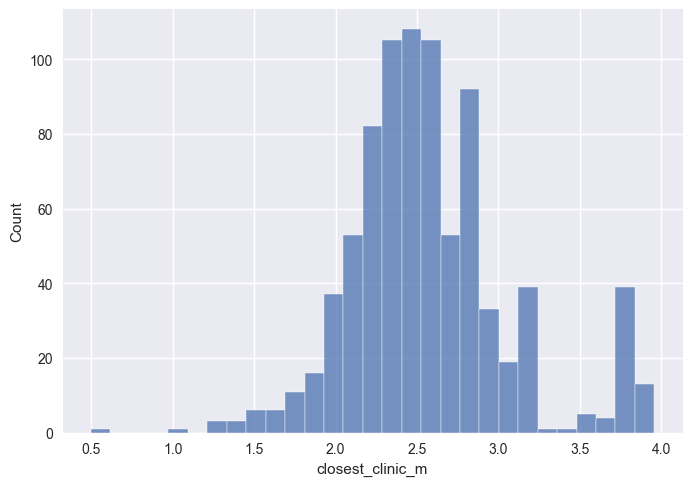

In [78]:
sns.histplot(apartments['closest_clinic_m'].map(np.log10))
#sns.displot(data=apartments['closest_tram_stop_m'].map(np.log), x="closest_tram_stop_m", hue="ad_type")

<Axes: >

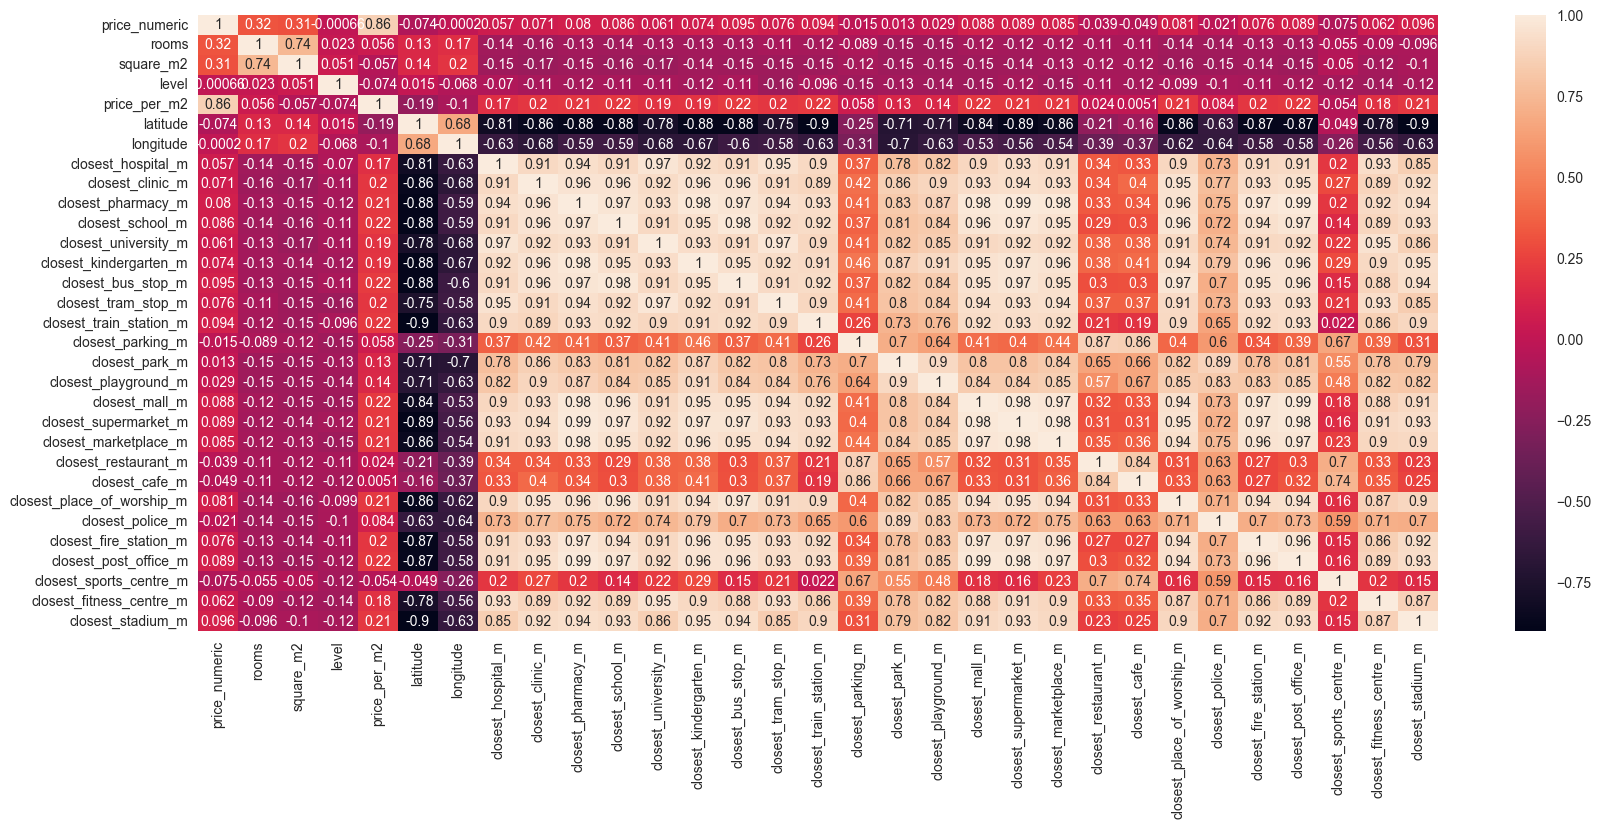

In [79]:
plt.figure(figsize=(20, 8))
sns.heatmap(data=apartments.corr(numeric_only=True), annot=True)

<Axes: >

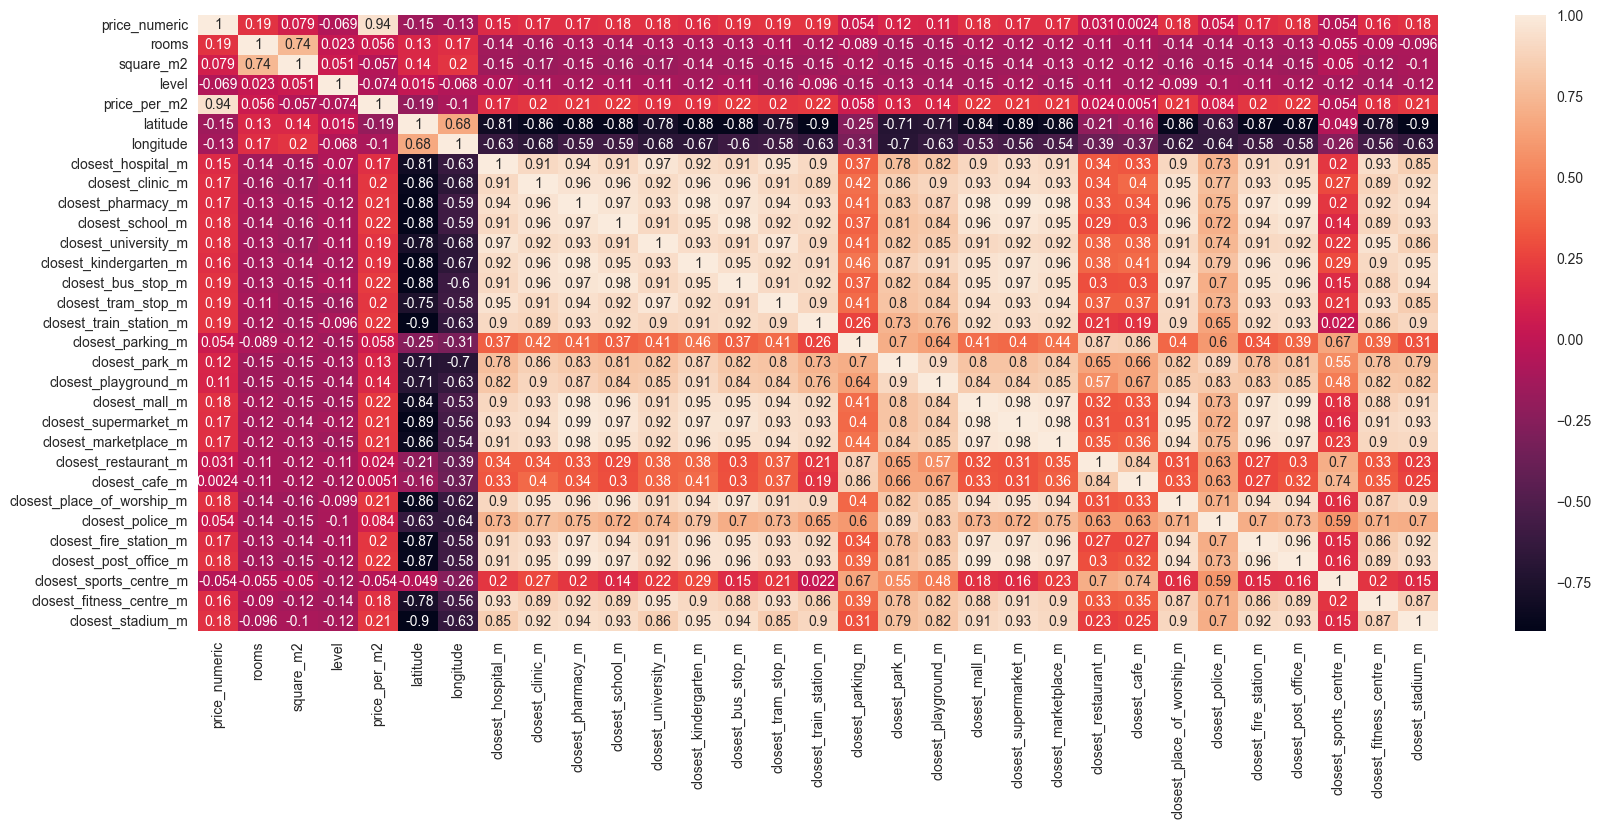

In [80]:
log_price_apartments = apartments.copy()
log_price_apartments['price_numeric'] = np.log(log_price_apartments['price_numeric'])
plt.figure(figsize=(20, 8))
sns.heatmap(data=log_price_apartments.corr(numeric_only=True), annot=True)


In [81]:
apartments.drop(labels=["latitude", "longitude"], axis=1, inplace=True)

sales = apartments[apartments['ad_type'] == 'Sale'].drop(labels="ad_type", axis=1)
sales.to_csv("../data/sales.csv", index=False)

rentals = apartments[apartments['ad_type'] == 'Rent'].drop(labels="ad_type", axis=1)
rentals.to_csv("../data/rentals.csv", index=False)